# DIA Target-Decoy FDR Analysis

This notebook analyzes DIA search results from pyXcorrDIA, comparing the performance of different scoring metrics:
- **LibCosine**: Library cosine similarity score
- **LibCosineZScore**: Z-score of LibCosine across chromatogram
- **XCorr**: Cross-correlation score at LibCosine peak

We'll plot ROC-like curves showing the number of target identifications vs. FDR (False Discovery Rate) for each metric.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load DIA Results

Load the TSV file containing the search results with target/decoy labels and scoring metrics.

In [16]:
# Load the DIA results
tsv_file = "Ast-Neo-15min-2mz-4ms-200agc-60000-70000.dia.tsv"
df = pd.read_csv(tsv_file, sep='\t')

# Convert IsTarget to boolean for easier filtering
df['is_target'] = df['IsTarget'] == 'Target'

print(f"Loaded {len(df)} results")
print(f"Targets: {df['is_target'].sum()}")
print(f"Decoys: {(~df['is_target']).sum()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loaded 40992 results
Targets: 21650
Decoys: 19342

Columns: ['Peptide', 'Charge', 'ProteinID', 'Mass', 'IsTarget', 'IsolationWindow', 'NumSpectraScored', 'LibCosine', 'LibCosineZScore', 'XCorr', 'RT', 'ScanID', 'PrecursorCosine', 'is_target']

First few rows:


,Peptide,Charge,ProteinID,Mass,IsTarget,IsolationWindow,NumSpectraScored,LibCosine,LibCosineZScore,XCorr,RT,ScanID,PrecursorCosine,is_target
0,GCVAQGCK,2,decoy_LIBRARY_CGQAVCGK,878.373860,Decoy,[438.4492-440.4501],40,0.8497,3.4464,-0.1107,6.79,65020,0.0000,False
1,FLENKVK,2,decoy_LIBRARY_VKNELFK,876.506903,Decoy,[438.4492-440.4501],40,0.6805,1.8831,0.0856,6.87,65773,0.0000,False
2,ECDNALR,2,LIBRARY_ECDNALR,876.375966,Target,[438.4492-440.4501],40,0.8668,2.7798,0.1239,6.92,66275,0.9127,True
3,IDFGEAAR,2,LIBRARY_IDFGEAAR,877.429382,Target,[438.4492-440.4501],40,0.9496,1.9945,0.3056,7.09,68032,0.0774,True
4,GILPSVHR,2,decoy_LIBRARY_HVSPLIGR,877.513386,Decoy,[438.4492-440.4501],40,0.7615,4.0579,-0.3975,7.09,68032,0.0000,False


## 3. Calculate FDR Curves

For each scoring metric, we'll:
1. Sort results by score (best = highest for LibCosine/LibCosineZScore/XCorr)
2. Calculate cumulative targets and decoys at each threshold
3. Calculate FDR = decoys / targets

In [17]:
def calculate_fdr_curve(df, score_column, ascending=False):
    """
    Calculate FDR curve for a given score column.
    
    Parameters:
    - df: DataFrame with 'is_target' column and score column
    - score_column: Name of the score column to sort by
    - ascending: Whether higher scores are better (False) or lower scores are better (True)
    
    Returns:
    - DataFrame with cumulative targets, decoys, and FDR
    """
    # Sort by score (best scores first)
    df_sorted = df.sort_values(score_column, ascending=ascending).copy()
    
    # Calculate cumulative counts
    df_sorted['cumulative_targets'] = df_sorted['is_target'].cumsum()
    df_sorted['cumulative_decoys'] = (~df_sorted['is_target']).cumsum()
    
    # Calculate FDR = decoys / targets (avoid division by zero)
    df_sorted['fdr'] = df_sorted['cumulative_decoys'] / df_sorted['cumulative_targets'].replace(0, np.nan)
    df_sorted['fdr'] = df_sorted['fdr'].fillna(0)
    
    return df_sorted[['cumulative_targets', 'cumulative_decoys', 'fdr', score_column]]


# Calculate FDR curves for each scoring metric
fdr_libcosine = calculate_fdr_curve(df, 'LibCosine', ascending=False)
fdr_libcosine_zscore = calculate_fdr_curve(df, 'LibCosineZScore', ascending=False)
fdr_xcorr = calculate_fdr_curve(df, 'XCorr', ascending=False)

print("FDR curves calculated successfully!")
print(f"\nLibCosine - Max targets at 1% FDR: {fdr_libcosine[fdr_libcosine['fdr'] <= 0.01]['cumulative_targets'].max()}")
print(f"LibCosineZScore - Max targets at 1% FDR: {fdr_libcosine_zscore[fdr_libcosine_zscore['fdr'] <= 0.01]['cumulative_targets'].max()}")
print(f"XCorr - Max targets at 1% FDR: {fdr_xcorr[fdr_xcorr['fdr'] <= 0.01]['cumulative_targets'].max()}")

FDR curves calculated successfully!

LibCosine - Max targets at 1% FDR: 1760
LibCosineZScore - Max targets at 1% FDR: 0
XCorr - Max targets at 1% FDR: 305


## 3.1 Investigate LibCosineZScore Issue

Before calculating FDR curves, let's investigate why LibCosineZScore appears to be problematic.

In [18]:
# Check correlation between LibCosine and LibCosineZScore
print("=== Investigating LibCosineZScore ===\n")

# Look at top LibCosine scores and their corresponding Z-scores
print("Top 10 by LibCosine:")
top_libcosine = df.nlargest(10, 'LibCosine')[['Peptide', 'IsTarget', 'LibCosine', 'LibCosineZScore']]
print(top_libcosine.to_string(index=False))

print("\n\nTop 10 by LibCosineZScore:")
top_zscore = df.nlargest(10, 'LibCosineZScore')[['Peptide', 'IsTarget', 'LibCosine', 'LibCosineZScore']]
print(top_zscore.to_string(index=False))

print("\n\nBottom 10 by LibCosineZScore:")
bottom_zscore = df.nsmallest(10, 'LibCosineZScore')[['Peptide', 'IsTarget', 'LibCosine', 'LibCosineZScore']]
print(bottom_zscore.to_string(index=False))

# Calculate correlation
correlation = df['LibCosine'].corr(df['LibCosineZScore'])
print(f"\n\nCorrelation between LibCosine and LibCosineZScore: {correlation:.4f}")

# Check if Z-scores might be negative or have unusual distribution
print(f"\nLibCosineZScore statistics:")
print(f"  Min: {df['LibCosineZScore'].min():.4f}")
print(f"  Max: {df['LibCosineZScore'].max():.4f}")
print(f"  Mean: {df['LibCosineZScore'].mean():.4f}")
print(f"  Median: {df['LibCosineZScore'].median():.4f}")

=== Investigating LibCosineZScore ===

Top 10 by LibCosine:
         Peptide IsTarget  LibCosine  LibCosineZScore
       ETWTANVGK   Target     0.9998           0.9057
       VDGALCMEK   Target     0.9998           1.0186
    AAISGENAGLVR   Target     0.9998           0.7864
      SEAYNTFSER   Target     0.9998           1.1077
        TITSSYYR   Target     0.9998           1.4743
    VVAGVANALAHK   Target     0.9997           1.1065
   NGYGTPMTSNAVR   Target     0.9997           1.5902
  AWGESTPLANKPGK   Target     0.9997           1.1077
      TFYSCTTEGR   Target     0.9996           0.7021
QVGSGVTTDQVQAEAK   Target     0.9996           0.5079


Top 10 by LibCosineZScore:
         Peptide IsTarget  LibCosine  LibCosineZScore
  LTIPKIVEVPVLIK    Decoy     0.8146           6.1510
    VASLLEPISVLK    Decoy     0.6906           6.1455
  QKSTVLTIPEIIIK   Target     0.4376           6.1270
     EATLQLSIVVK    Decoy     0.5320           6.1184
     DMCGQLAVFLK    Decoy     0.7002           

## 4. Plot ROC-like Curves: Number of Targets vs FDR

This plot shows how many target peptides can be identified at different FDR thresholds for each scoring metric.

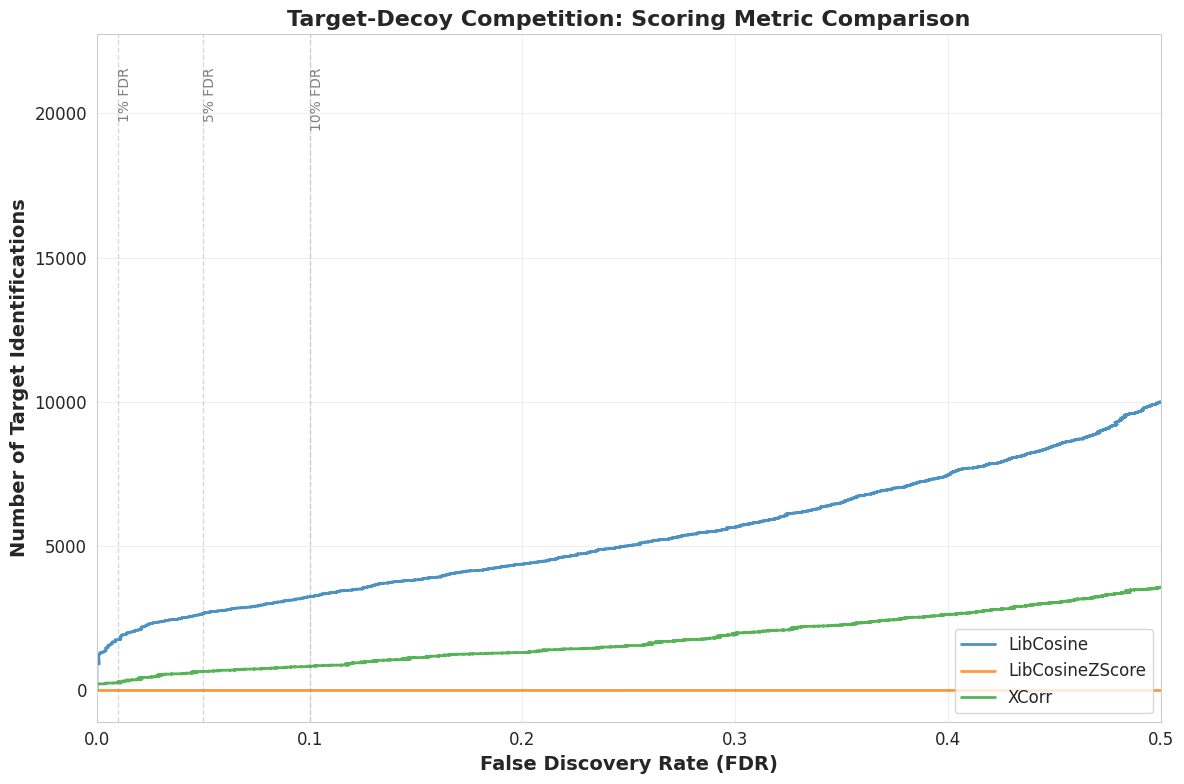


=== Summary at Common FDR Thresholds ===

1% FDR:
  LibCosine: 1760 targets
  LibCosineZScore: 0 targets
  XCorr: 305 targets

5% FDR:
  LibCosine: 2667 targets
  LibCosineZScore: 0 targets
  XCorr: 663 targets

10% FDR:
  LibCosine: 3245 targets
  LibCosineZScore: 0 targets
  XCorr: 845 targets


In [19]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot FDR curves
ax.plot(fdr_libcosine['fdr'], fdr_libcosine['cumulative_targets'], 
        label='LibCosine', linewidth=2, alpha=0.8)
ax.plot(fdr_libcosine_zscore['fdr'], fdr_libcosine_zscore['cumulative_targets'], 
        label='LibCosineZScore', linewidth=2, alpha=0.8)
ax.plot(fdr_xcorr['fdr'], fdr_xcorr['cumulative_targets'], 
        label='XCorr', linewidth=2, alpha=0.8)

# Add vertical lines for common FDR thresholds
fdr_thresholds = [0.01, 0.05, 0.10]
for fdr_threshold in fdr_thresholds:
    ax.axvline(x=fdr_threshold, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(fdr_threshold, ax.get_ylim()[1] * 0.95, f'{fdr_threshold*100:.0f}% FDR', 
            rotation=90, verticalalignment='top', fontsize=10, color='gray')

ax.set_xlabel('False Discovery Rate (FDR)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Target Identifications', fontsize=14, fontweight='bold')
ax.set_title('Target-Decoy Competition: Scoring Metric Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)  # Focus on 0-50% FDR range

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary at Common FDR Thresholds ===")
for fdr_threshold in [0.01, 0.05, 0.10]:
    print(f"\n{fdr_threshold*100:.0f}% FDR:")
    print(f"  LibCosine: {fdr_libcosine[fdr_libcosine['fdr'] <= fdr_threshold]['cumulative_targets'].max()} targets")
    print(f"  LibCosineZScore: {fdr_libcosine_zscore[fdr_libcosine_zscore['fdr'] <= fdr_threshold]['cumulative_targets'].max()} targets")
    print(f"  XCorr: {fdr_xcorr[fdr_xcorr['fdr'] <= fdr_threshold]['cumulative_targets'].max()} targets")

## 5. Score Distribution by Target/Decoy Status

Let's examine the distribution of scores for targets vs decoys to understand the discriminatory power of each metric.

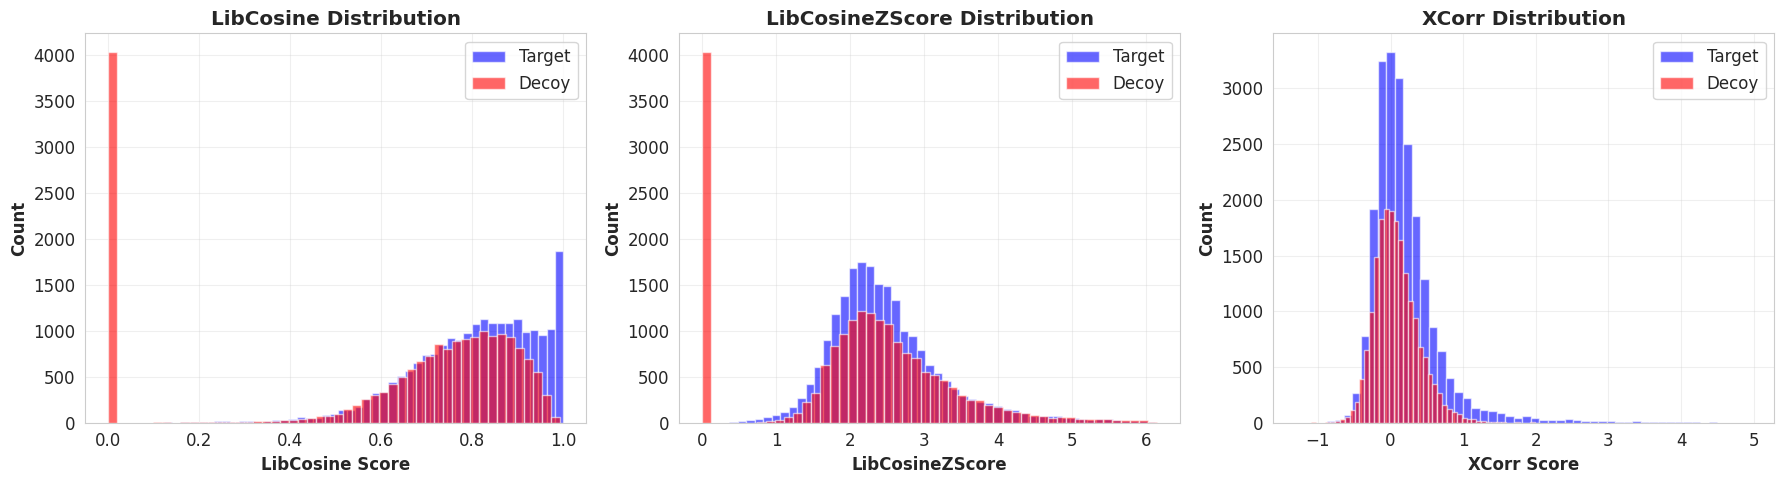


=== Mean Scores ===
LibCosine - Target: 0.8075, Decoy: 0.6079
LibCosineZScore - Target: 2.4928, Decoy: 2.0669
XCorr - Target: 0.1972, Decoy: 0.0811


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LibCosine distribution
axes[0].hist(df[df['is_target']]['LibCosine'], bins=50, alpha=0.6, label='Target', color='blue')
axes[0].hist(df[~df['is_target']]['LibCosine'], bins=50, alpha=0.6, label='Decoy', color='red')
axes[0].set_xlabel('LibCosine Score', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('LibCosine Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LibCosineZScore distribution
axes[1].hist(df[df['is_target']]['LibCosineZScore'], bins=50, alpha=0.6, label='Target', color='blue')
axes[1].hist(df[~df['is_target']]['LibCosineZScore'], bins=50, alpha=0.6, label='Decoy', color='red')
axes[1].set_xlabel('LibCosineZScore', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('LibCosineZScore Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# XCorr distribution
axes[2].hist(df[df['is_target']]['XCorr'], bins=50, alpha=0.6, label='Target', color='blue')
axes[2].hist(df[~df['is_target']]['XCorr'], bins=50, alpha=0.6, label='Decoy', color='red')
axes[2].set_xlabel('XCorr Score', fontweight='bold')
axes[2].set_ylabel('Count', fontweight='bold')
axes[2].set_title('XCorr Distribution', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print mean scores
print("\n=== Mean Scores ===")
print(f"LibCosine - Target: {df[df['is_target']]['LibCosine'].mean():.4f}, Decoy: {df[~df['is_target']]['LibCosine'].mean():.4f}")
print(f"LibCosineZScore - Target: {df[df['is_target']]['LibCosineZScore'].mean():.4f}, Decoy: {df[~df['is_target']]['LibCosineZScore'].mean():.4f}")
print(f"XCorr - Target: {df[df['is_target']]['XCorr'].mean():.4f}, Decoy: {df[~df['is_target']]['XCorr'].mean():.4f}")

## 6. Decoy Rate by Score Range

Analyze how the decoy rate changes across different score ranges to validate the target-decoy competition.

=== Decoy Rate by LibCosine Score Range ===

LibCosine [0.95-1.00): Targets=3569, Decoys= 448, Decoy%= 11.2%
LibCosine [0.90-0.95): Targets=2790, Decoys=1722, Decoy%= 38.2%
LibCosine [0.85-0.90): Targets=2988, Decoys=2321, Decoy%= 43.7%
LibCosine [0.80-0.85): Targets=2991, Decoys=2451, Decoy%= 45.0%
LibCosine [0.00-0.80): Targets=9312, Decoys=12400, Decoy%= 57.1%


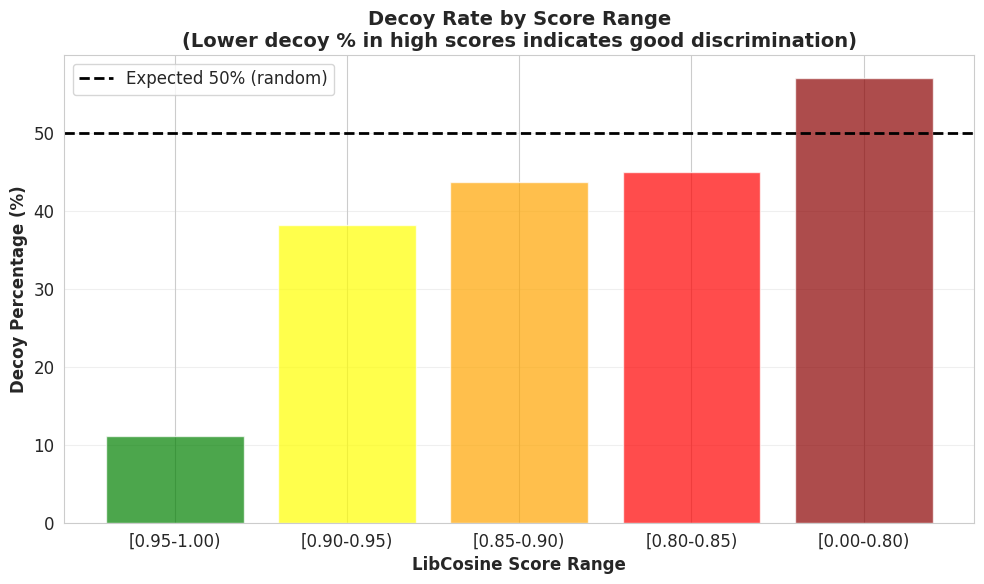

In [21]:
# Analyze decoy rate by LibCosine score range
score_ranges = [(0.95, 1.0), (0.90, 0.95), (0.85, 0.90), (0.80, 0.85), (0.0, 0.80)]

print("=== Decoy Rate by LibCosine Score Range ===\n")
for low, high in score_ranges:
    mask = (df['LibCosine'] >= low) & (df['LibCosine'] < high)
    n_targets = df[mask & df['is_target']].shape[0]
    n_decoys = df[mask & ~df['is_target']].shape[0]
    total = n_targets + n_decoys
    if total > 0:
        decoy_pct = (n_decoys / total) * 100
        print(f"LibCosine [{low:.2f}-{high:.2f}): "
              f"Targets={n_targets:4d}, Decoys={n_decoys:4d}, "
              f"Decoy%={decoy_pct:5.1f}%")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ranges_labels = []
decoy_percentages = []

for low, high in score_ranges:
    mask = (df['LibCosine'] >= low) & (df['LibCosine'] < high)
    n_targets = df[mask & df['is_target']].shape[0]
    n_decoys = df[mask & ~df['is_target']].shape[0]
    total = n_targets + n_decoys
    if total > 0:
        decoy_pct = (n_decoys / total) * 100
        ranges_labels.append(f'[{low:.2f}-{high:.2f})')
        decoy_percentages.append(decoy_pct)

ax.bar(ranges_labels, decoy_percentages, color=['green', 'yellow', 'orange', 'red', 'darkred'], alpha=0.7)
ax.axhline(y=50, color='black', linestyle='--', linewidth=2, label='Expected 50% (random)')
ax.set_xlabel('LibCosine Score Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Decoy Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Decoy Rate by Score Range\n(Lower decoy % in high scores indicates good discrimination)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Visualize Chromatograms for Top Peptides

Load the detailed chromatogram data and plot LibCosine profiles for the top peptides.

In [22]:
# Load the chromatogram data from parquet file
import pyarrow.parquet as pq

parquet_file = "Ast-Neo-15min-2mz-4ms-200agc-60000-70000.dia-chrom.parquet"
chrom_df = pd.read_parquet(parquet_file)

print(f"Loaded {len(chrom_df)} chromatogram points")
print(f"\nChromatogram columns: {list(chrom_df.columns)}")
print(f"\nUnique peptides: {chrom_df['peptide_id'].nunique()}")
print(f"\nFirst few rows:")
print(chrom_df.head(10))

Loaded 1752975 chromatogram points

Chromatogram columns: ['peptide_id', 'peptide_sequence', 'charge', 'is_target', 'scan_id', 'retention_time', 'xcorr_raw', 'xcorr_smoothed', 'lib_cosine_target', 'lib_cosine_decoy']

Unique peptides: 43944

First few rows:
                peptide_id peptide_sequence  charge  is_target  scan_id  \
1082920  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    60148   
1082921  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    60399   
1082922  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    60650   
1082923  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    60901   
1082924  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    61152   
1082925  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    61403   
1082926  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    61654   
1082927  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    61905   
1082928  AAAAAAAAAATGK_2_D    AAAAAAAAAATGK       2      False    6

In [24]:
# Calculate FDR for each peptide in the TSV results using LibCosine
# Sort by LibCosine (descending) and calculate cumulative FDR
df_sorted = df.sort_values('LibCosine', ascending=False).copy()
df_sorted['cumulative_targets'] = (~df_sorted['IsDecoy']).cumsum()
df_sorted['cumulative_decoys'] = df_sorted['IsDecoy'].cumsum()
df_sorted['fdr'] = df_sorted['cumulative_decoys'] / df_sorted['cumulative_targets'].replace(0, 1)

# Get the 4 peptides with the lowest FDR
top4_peptides = df_sorted.nsmallest(4, 'fdr')

print("Top 4 peptides with lowest FDR:")
print(top4_peptides[['PeptideID', 'PeptideSequence', 'LibCosine', 'LibCosineZScore', 'fdr', 'IsDecoy']].to_string())

# Extract their peptide IDs for matching with chromatogram data
top4_ids = top4_peptides['PeptideID'].tolist()

KeyError: 'IsDecoy'